In [ ]:
%pip install numpy
%pip install matplotlib
%pip install tqdm
%pip install gymnasium
%pip install torch
%pip install tensorboard


## Environment

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
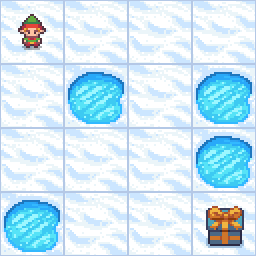

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from enum import Enum
import gymnasium as gym

MAP = [
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG"
]

GAMMA = 0.999

def create_environment(success_rate):
  return gym.make("FrozenLake-v1", map_name="4x4", render_mode='rgb_array', success_rate=success_rate, is_slippery=True, desc=MAP)

env = create_environment(0.5)
env.reset()
env.render()

## Utilities

In [9]:
def get_free_cells(map_str):
  free_cells = []
  for i, row in enumerate(map_str):
    for j, cell in enumerate(row):
      if cell in 'SF':
        free_cells.append(4 * i + j)
  return free_cells

def visualize_policy(ax, map_str, V, pi):
  H = len(map_str)
  W = len(map_str[0])

  free_cells = get_free_cells(map_str)
  V_viz = V.copy()
  V_viz[:] = None
  V_viz[free_cells] = V[free_cells]
  h = ax.imshow(V_viz.reshape([H, W]), vmin=-1.0, vmax=1.0)

  u = (pi == 2).astype(float) - (pi == 0).astype(float)
  v = (pi == 3).astype(float) - (pi == 1).astype(float)
  uu = float('nan') * u
  uu[free_cells] = u[free_cells]
  u = uu

  u = u.reshape([H, W])
  v = v.reshape([H, W])

  ax.quiver(
      list(range(W)),
      list(range(H)),
      u,
      v,
      color='r',
  )

  return h

## Dynamic Programming

In [12]:
"""
We will use env.unwrapped.P to get the transition and reward functions.

env.unwrapped.P is a dictionary where P[s][a] is a list of tuples:
[(probability, next_state, reward, done), ...]
"""

import gymnasium as gym
import numpy as np

env = create_environment(0.5)

def policy_evaluation(env, map_str, policy, gamma, theta=1e-8, max_iterations=None):
    """
    Evaluate the value function for a given determinstic policy (Policy Evaluation step).
    Uses the Bellman expectation equation iteratively.
    """

    S = get_free_cells(map_str)

    # Initialize value function V(s) to zeros for all states.
    # Note that terminal states (hole and goal) must have V set to 0.
    V = np.zeros(env.observation_space.n)

    it = 0
    while max_iterations is None or it < max_iterations:
      it += 1

      V_new = np.zeros_like(V)
      # Iterate over all states
      for s in S:
          action = policy[s]
          action_prob = 1.0

          # Iterate over all possible outcomes (next_state, reward, done_status)
          # env.P[s][a] gives a list of tuples: [(prob, next_state, reward, done), ...]
          # NOTE: For a stochastic policy, this loop will be inside another loop the
          # iterates over actions.
          for next_state_prob, next_state, reward, done in env.unwrapped.P[s][action]:
              # Bellman expectation equation.
              V_new[s] += action_prob * next_state_prob * (reward + gamma * V[next_state])
      delta = np.max(np.abs(V_new - V))
      V = V_new
      # Check for convergence
      if delta < theta:
          break
    return V

def policy_improvement(env, V, gamma):
    """
    Improve the policy based on the current value function (Policy Improvement step).
    Makes the policy greedy with respect to the current V.
    """
    # Initialize a new policy
    new_policy = np.zeros([env.observation_space.n])
    # Iterate over all states
    for s in range(env.observation_space.n):
      # Calculate Q-values for all actions in the current state
      Q_s = np.zeros(env.action_space.n)
      for a in range(env.action_space.n):
        for next_state_prob, next_state, reward, done in env.unwrapped.P[s][a]:
          # Calculate expected future reward
          Q_s[a] += next_state_prob * (reward + gamma * V[next_state])

      # Choose the action(s) with the highest Q-value
      new_policy[s] = np.argmax(Q_s)
    return new_policy

def policy_iteration(env, map_str, gamma, evaluation_theta=1e-8, evaluation_max_iterations=None, return_intermediate_results=False):
  """
  Main policy iteration algorithm loop.
  Alternates between policy evaluation and policy improvement until convergence.
  """

  output = []

  print("Starting Policy Iteration...")
  policy = np.zeros([env.observation_space.n], dtype=np.int32)

  while True:
    # Policy Evaluation step
    V = policy_evaluation(
        env, map_str, policy, gamma, theta=evaluation_theta, max_iterations=evaluation_max_iterations)

    if return_intermediate_results:
      output.append((policy, V))

    # Policy Improvement step
    new_policy = policy_improvement(env, V, gamma)

    # Check for policy convergence (if the policy hasn't changed)
    if np.array_equal(new_policy, policy):
        print("Policy converged.")
        break

    policy = new_policy

  return policy, V, output

# Run the policy iteration algorithm
optimal_policy, optimal_V, all_pi_v = policy_iteration(env, MAP, gamma=0.999, return_intermediate_results=True)

print("\nOptimal Value Function V(s) (reshaped 4x4):")
print(optimal_V.reshape(4, 4))
print("\nOptimal Policy (0: left, 1: down, 2: right, 3: up):")
print(optimal_policy.reshape(4, 4))

Starting Policy Iteration...
Policy converged.

Optimal Value Function V(s) (reshaped 4x4):
[[0.85119553 0.84115816 0.83448882 0.83116081]
 [0.85460375 0.         0.41682716 0.        ]
 [0.86143382 0.87854316 0.78433002 0.        ]
 [0.         0.93596325 0.96654709 0.        ]]

Optimal Policy (0: left, 1: down, 2: right, 3: up):
[[0. 3. 3. 3.]
 [0. 0. 3. 0.]
 [3. 1. 0. 0.]
 [0. 2. 1. 0.]]


In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

current_idx = 0
max_idx = len(all_pi_v) - 1

output_area = widgets.Output()

def plot_policy(idx):
    with output_area:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 6))
        # visualize_policy expects (ax, map_str, V, pi)
        # all_pi_v stores (policy, V) tuples
        visualize_policy(ax, MAP, all_pi_v[idx][1], all_pi_v[idx][0])
        ax.set_title(f"Iteration {idx}")
        fig.colorbar(ax.images[0])
        plt.show()

def update_index(new_idx):
    global current_idx
    if new_idx == current_idx:
      return
    current_idx = new_idx
    plot_policy(current_idx)

def on_prev_button_clicked(b):
    update_index(max(current_idx - 1, 0))

def on_next_button_clicked(b):
    update_index(min(current_idx + 1, max_idx))

first_button = widgets.Button(description="First")
prev_button = widgets.Button(description="Previous")
next_button = widgets.Button(description="Next")
last_button = widgets.Button(description="Last")

first_button.on_click(lambda b: update_index(0))
prev_button.on_click(on_prev_button_clicked)
next_button.on_click(on_next_button_clicked)
last_button.on_click(lambda b: update_index(max_idx))

# Display initial plot
plot_policy(current_idx)

display(widgets.HBox([first_button, prev_button, next_button, last_button]), output_area)

Output()